<a href="https://colab.research.google.com/github/svetlanama/ai_practice/blob/dev/DZ_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn import metrics

import matplotlib.pyplot as plt



In [59]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module2/data/ship_passengers.csv",
                 index_col="Unnamed: 0")
df2 = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module2/data/ship_passengers.csv",
                 index_col="Unnamed: 0")

In [60]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [61]:
df = df[['pclass', 'age', 'embarked', 'fare']]
df.head()

,pclass,age,embarked,fare
0,3,22.0,S,7.2500
1,1,38.0,C,71.2833
2,3,26.0,S,7.9250
3,1,35.0,S,53.1000
4,3,35.0,S,8.0500


# Завдання 1
Очистіть дані від викидів(лише `fare`), розділіть на тренувальну та тестову чатини

<Axes: >

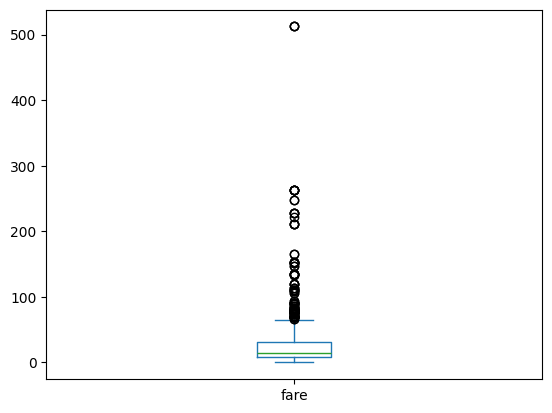

In [62]:
df['fare'].plot(kind='box')


In [63]:
df = df[df['fare'] < 300]
df

,pclass,age,embarked,fare
0,3,22.0,S,7.2500
1,1,38.0,C,71.2833
2,3,26.0,S,7.9250
3,1,35.0,S,53.1000
4,3,35.0,S,8.0500
...,...,...,...,...
886,2,27.0,S,13.0000
887,1,19.0,S,30.0000
888,3,NaN,S,23.4500
889,1,26.0,C,30.0000


In [64]:
y = df['fare']
X = df.drop(columns='fare')

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42)

# Завдання 2
Створіть Pipeline для обробки даних

In [66]:
num_columns = X.select_dtypes(include="number").columns
cat_columns = X.select_dtypes(include="object").columns

num_transformer = Pipeline(
  steps=[("imputer", KNNImputer(n_neighbors=3))]
    )

num_transformer

Pipeline(steps=[('imputer', KNNImputer(n_neighbors=3))])

In [67]:
cat_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")),
           ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=3
                                  ))])
cat_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=3))])

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_columns),
        ("cat", cat_transformer, cat_columns),
    ]
)

preprocessor.set_output(transform='pandas')
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  KNNImputer(n_neighbors=3))]),
                                 Index(['pclass', 'age'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=3))]),
                                 Index(['embarked'], dtype='object'))])

# Завдання 3
Об'єднайте дерево рішень з препроцесором та натренуйте їх

In [69]:
model = Pipeline(
    [("prep", preprocessor),
     ("tree", tree.DecisionTreeRegressor(max_depth=10,
                                         min_samples_leaf=4,
                                         min_samples_split=6,
                                         random_state=42)
     )
    ]
)

model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=3))]),
                                                  Index(['pclass', 'age'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=3))]),
                                                  Index(['embarked'], dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=4,
                                       min_samples_split=6, random_state=42))])

In [70]:
model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=3))]),
                                                  Index(['pclass', 'age'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=3))]),
                                                  Index(['embarked'], dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=4,
                                       min_samples_split=6, random_state=42))])

In [71]:

model['prep'].set_output(transform='pandas')
model['prep'].transform(X_train)

,num__pclass,num__age,cat__embarked
709,3.0,26.333333,0.0
239,2.0,33.000000,2.0
382,3.0,32.000000,2.0
794,3.0,25.000000,2.0
684,2.0,60.000000,2.0
...,...,...,...
106,3.0,21.000000,2.0
271,3.0,25.000000,2.0
863,3.0,26.333333,2.0
436,3.0,21.000000,2.0


# Завдання 4
Виведіть основні метрики моделі

In [75]:
def get_metrics(df, y_true, y_pred, name="model"):
  df = pd.DataFrame()

  df.loc["MAE", name] = metrics.mean_absolute_error(y_true, y_pred)
  df.loc["RMSE", name] = metrics.mean_squared_error(y_true, y_pred) ** 0.5
  df.loc["R2", name] = metrics.r2_score(y_true, y_pred)

  return df.round(2)

df_metrics = pd.DataFrame()

df_metrics["train"] = get_metrics(df, y_train, model.predict(X_train))
df_metrics["test"] = get_metrics(df, y_test, model.predict(X_test))

df_metrics

,train,test
MAE,14.19,17.79
RMSE,27.17,33.13
R2,0.58,0.22


Text(0.5, 1.0, 'R2 vs tree depth')

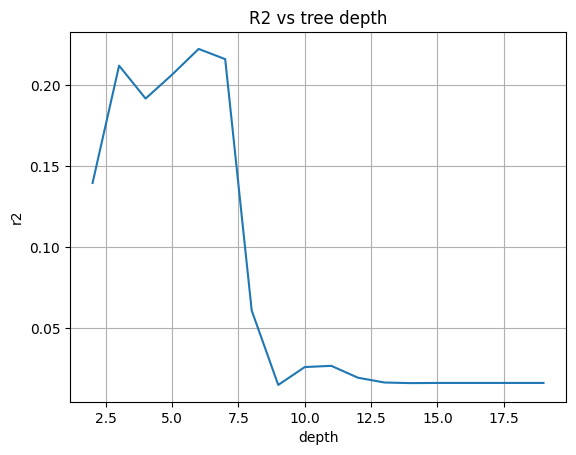

In [32]:
r2 = []
depths = list(range(2, 20))

for depth in depths:
    model = Pipeline(
        [("prep", preprocessor),
        ("tree", tree.DecisionTreeRegressor(max_depth=depth,
                                            random_state=42)
        )
        ]
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2.append(metrics.r2_score(y_pred, y_test))


plt.plot(depths, r2)
plt.xlabel('depth')
plt.ylabel('r2')
plt.grid()
plt.title('R2 vs tree depth')

# Завдання 5
Змініть параметри моделі та попробуйте покращити результат

Попробуйте:
* не видаляти викиди
* змінити обробку даних(imputer(SimpleImputer vs KNNImputer) та кодування категоріальних даних(OneHotEncoder vs OrdinaryEncoder))
* змінити параметри дерева(глибина, кількість точок у листках тощо)

In [80]:
y = df2['fare']
X = df2.drop(columns='fare')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42)

num_columns = X.select_dtypes(include="number").columns
cat_columns = X.select_dtypes(include="object").columns

# numeric
num_transformer = Pipeline(
  steps=[("imputer", SimpleImputer(strategy="most_frequent"))]
    )

num_transformer

# categorial
cat_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")),
           ("encoder", OrdinalEncoder())])
cat_transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_columns),
        ("cat", cat_transformer, cat_columns),
    ]
)

preprocessor.set_output(transform='pandas')
preprocessor

# tree
model2 = Pipeline(
    [("prep", preprocessor),
     ("tree", tree.DecisionTreeRegressor(max_depth=7,
                                         min_samples_leaf=4,
                                         min_samples_split=6,
                                         random_state=42)
     )
    ]
)

model2
# train
model2.fit(X_train, y_train)

df2_metrics = pd.DataFrame()

df2_metrics["train"] = get_metrics(df2, y_train, model2.predict(X_train))
df2_metrics["test"] = get_metrics(df2, y_test, model2.predict(X_test))

df2_metrics

,train,test
MAE,9.94,16.43
RMSE,27.19,40.72
R2,0.73,-0.07


# Завдання 6
Збережіть модель

In [30]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']